In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
train = pd.read_csv('train.csv')
train.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


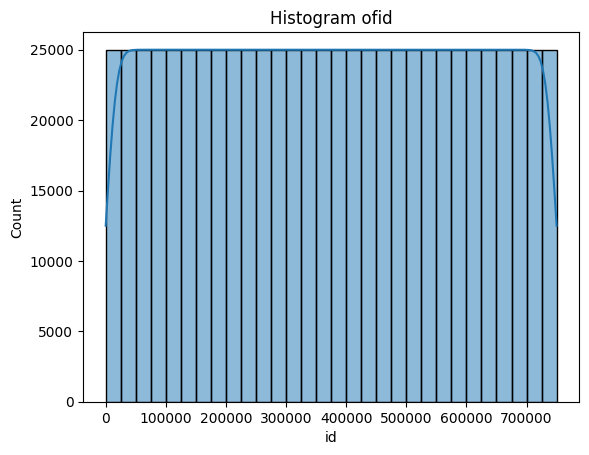

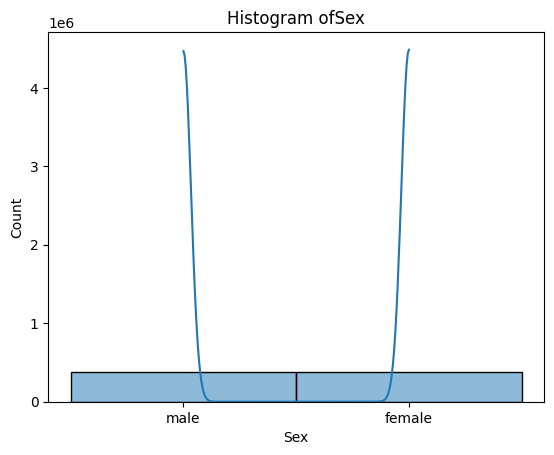

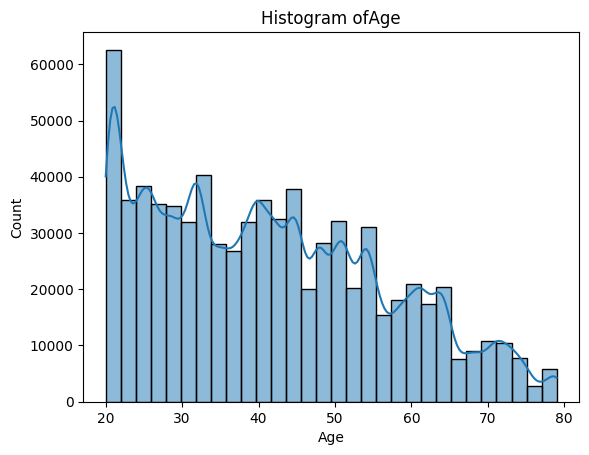

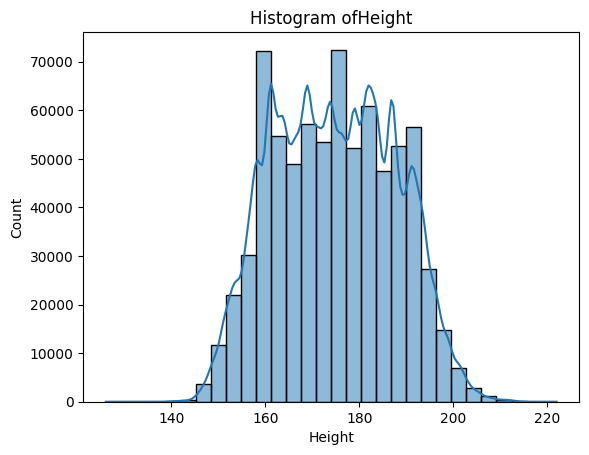

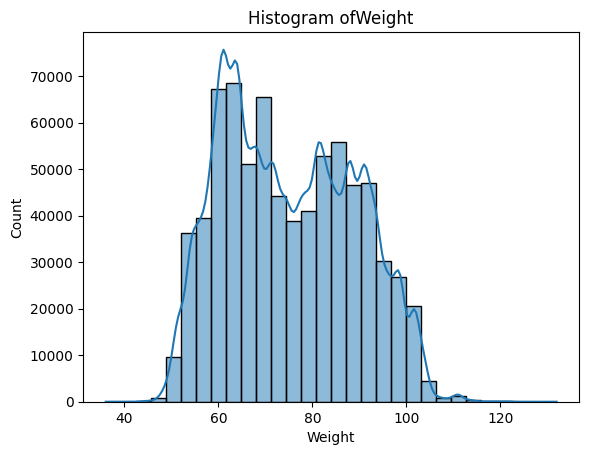

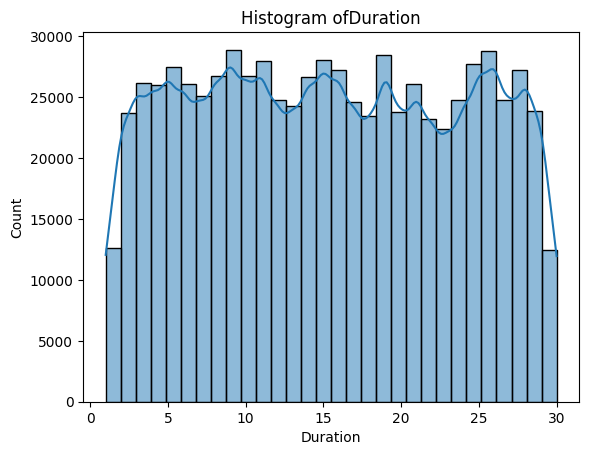

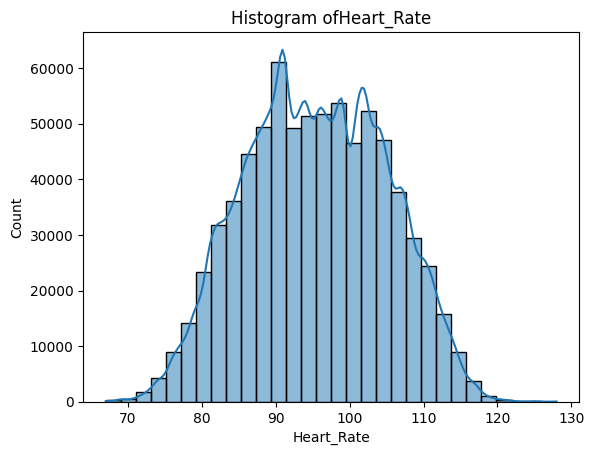

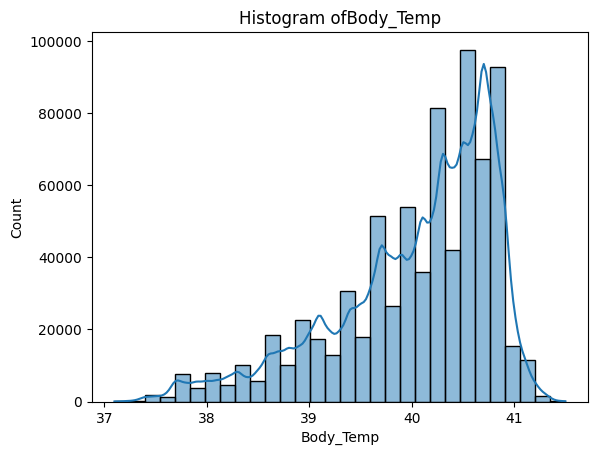

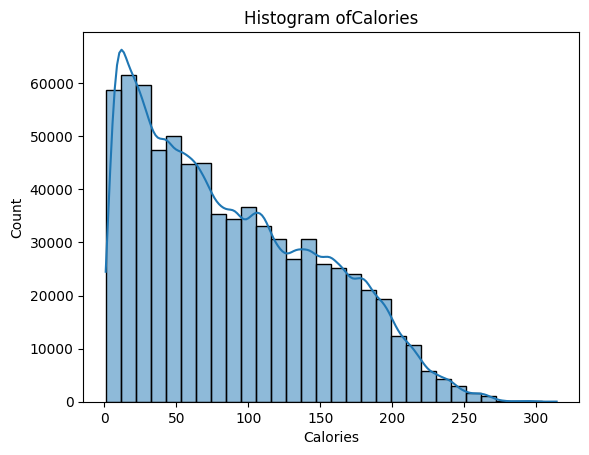

In [3]:
#lets look at the distribution of all categories
for i in train.columns:
    plt.figure()
    sns.histplot(train[i], bins=30, kde=True)
    plt.title("Histogram of" + str(i))
    plt.show()

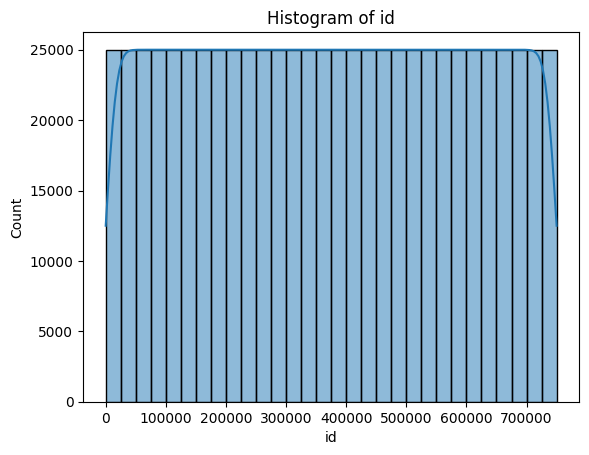

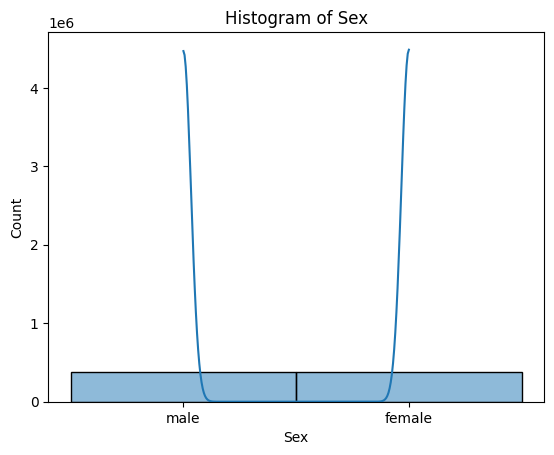

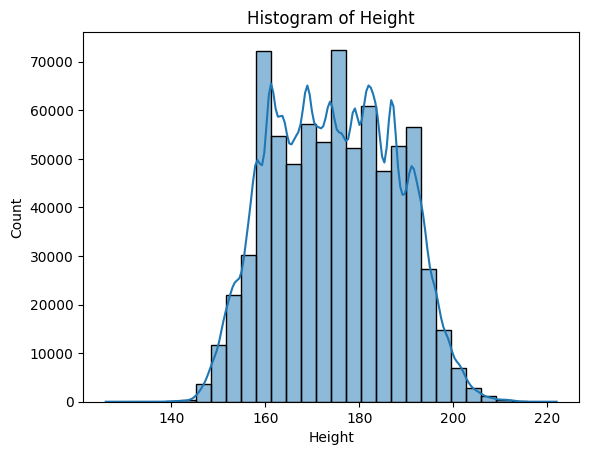

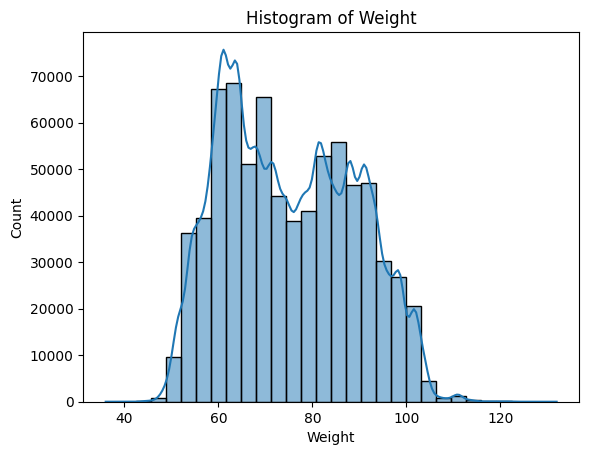

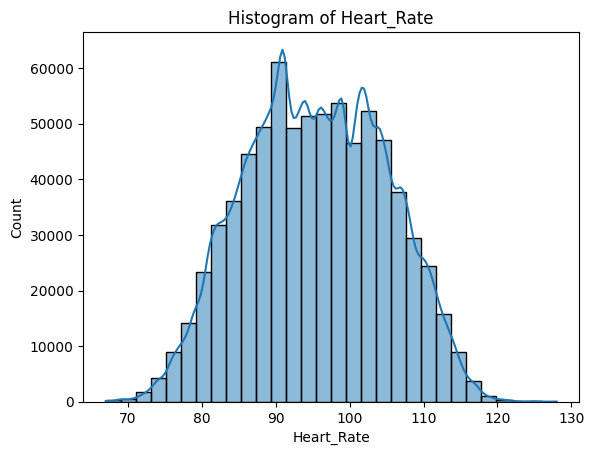

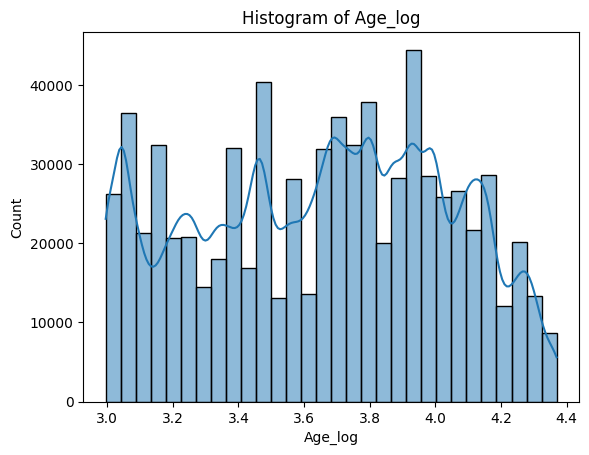

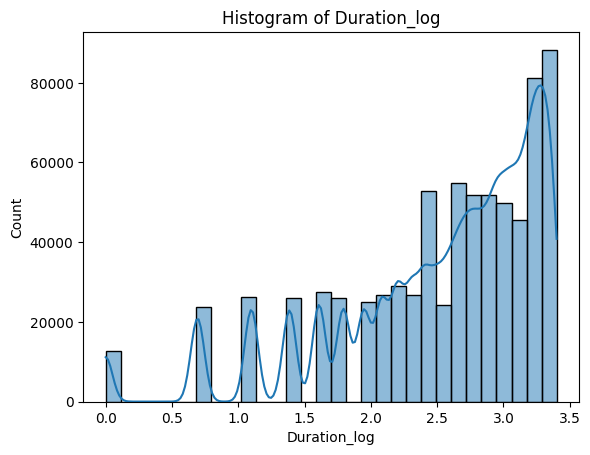

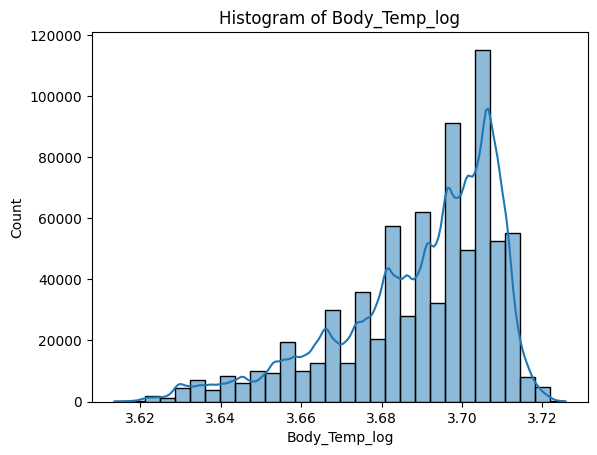

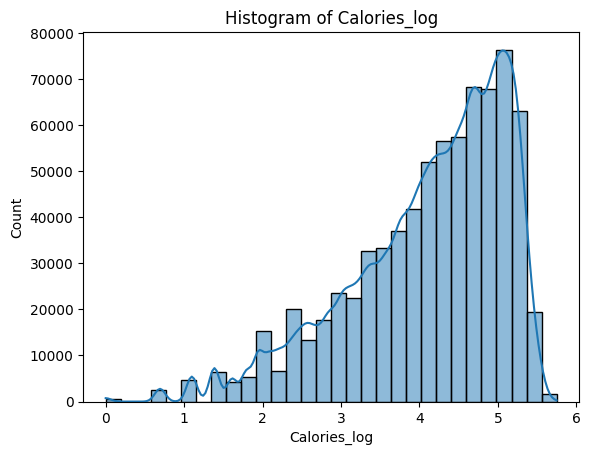

In [4]:
#lets transform some cols using ln for normal distribution purposes
import numpy as np
#lets transform Age, Duration, Body_Temp, Calories
cols_to_transform = ['Age', 'Duration', 'Body_Temp', 'Calories']
df_dist = train.copy()

for i in cols_to_transform:
    df_dist[i + str("_log")] = np.log(train[i])

#drop before transformation cols
df_dist = df_dist.drop(columns=cols_to_transform)
#lets look at all cols now

for i in df_dist.columns:
    plt.figure()
    sns.histplot(df_dist[i], bins=30, kde=True)
    plt.title("Histogram of " + str(i))
    plt.show()


In [5]:
from sklearn.model_selection import train_test_split
#lets drop ID
df_dist = df_dist.drop(columns='id')
#lets split the data
Target = "Calories_log"
X = df_dist.drop(columns=[Target])
y = df_dist[Target]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,     # 20% test, 80% train
    random_state=42,    # reproducibility
    stratify = y        #this attempts to balance the data
)

In [6]:
#lets do one hot encoder for Sex
#below is how to do OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

ohe = OneHotEncoder(
    handle_unknown="ignore",   # prevents crash on new categories
    sparse_output=False        # returns pandas-friendly dense output
)

X_train_cat = ohe.fit_transform(X_train[cat_cols])

X_test_cat = ohe.transform(X_test[cat_cols])

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

#want new columns to test whether they improved our model or not and we can compare quickly to the old model
X_train_final = pd.concat(
    [X_train.drop(columns=cat_cols), X_train_cat],
    axis=1
)

X_test_final = pd.concat(
    [X_test.drop(columns=cat_cols), X_test_cat],
    axis=1
)

In [7]:
X_train.head()


,Sex,Height,Weight,Heart_Rate,Age_log,Duration_log,Body_Temp_log
265083,female,161.0,61.0,76.0,3.044522,2.079442,3.678829
478727,male,193.0,93.0,103.0,3.044522,3.258097,3.713572
63313,female,159.0,58.0,91.0,3.912023,2.079442,3.673766
601870,female,157.0,55.0,87.0,3.401197,1.791759,3.668677
501877,female,160.0,61.0,93.0,3.583519,2.302585,3.683867


In [8]:
df_dist['dur_times_body_temp'] = df_dist['Body_Temp_log'] * df_dist['Duration_log']
df_dist['dur_times_age'] = df_dist['Duration_log'] * df_dist['Age_log']

In [9]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_squared_log_error
xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

xgb.fit(X_train_final, y_train)

preds = xgb.predict(X_test_final)

# print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
# print("R²:", r2_score(y_test, preds))

# from sklearn.metrics import mean_squared_log_error
# import numpy as np

# convert back to real space
preds_real = np.exp(preds)
y_test_real = np.exp(y_test)

rmsle = np.sqrt(mean_squared_log_error(y_test_real, preds_real))
print("RMSLE:", rmsle)

feat_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train_final.columns
).sort_values(ascending=False)

print(feat_importance.head(20))

RMSLE: 0.05998574588246959
Duration_log     0.724621
Body_Temp_log    0.207172
Heart_Rate       0.033901
Sex_male         0.012709
Sex_female       0.010577
Age_log          0.009718
Weight           0.001059
Height           0.000243
dtype: float32


In [10]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_dist["Duration_log"], df_dist["Calories_log"])

print("Pearson r:", corr)
print("p-value:", p_value)

#duration and calories high correlation and perfect p value

corr, p_value = pearsonr(df_dist["Body_Temp_log"], df_dist["Calories_log"])

print("Pearson r:", corr)
print("p-value:", p_value)

Pearson r: 0.9795942092549609
p-value: 0.0
Pearson r: 0.9531240216681321
p-value: 0.0


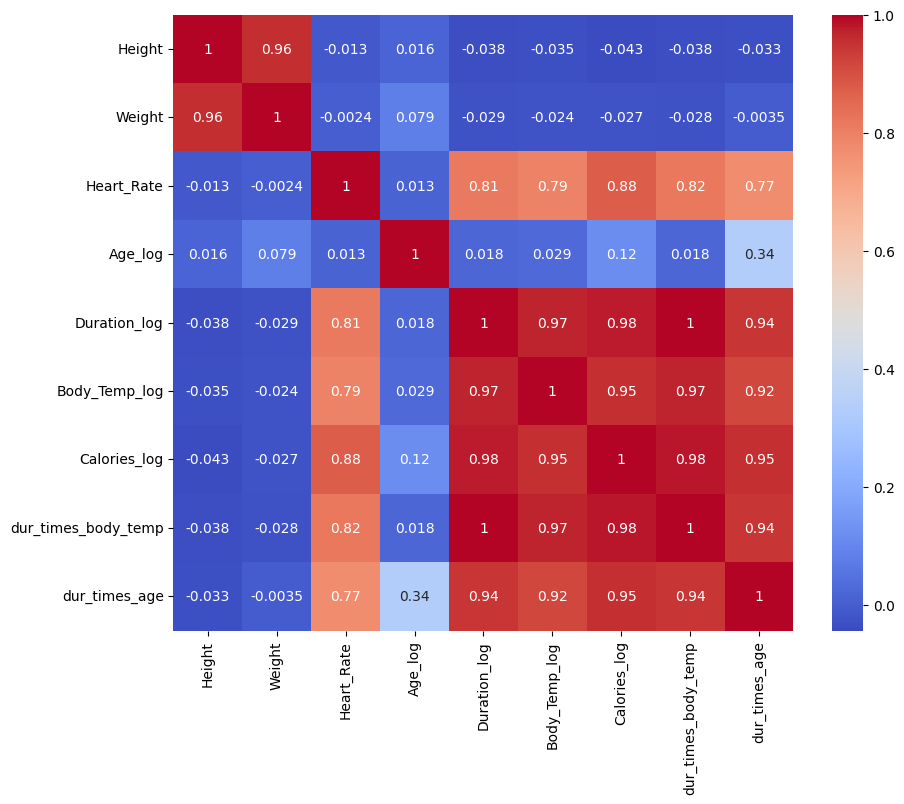

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df_dist.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [12]:
df_dist.shape
#lets feature engineer
df_dist['dur_times_body_temp'] = df_dist['Body_Temp_log'] * df_dist['Duration_log']
df_dist['dur_times_age'] = df_dist['Duration_log'] * df_dist['Age_log']
